In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/housing.csv")

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.shape

(506, 14)

In [5]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [6]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["medv"].describe()

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: medv, dtype: float64

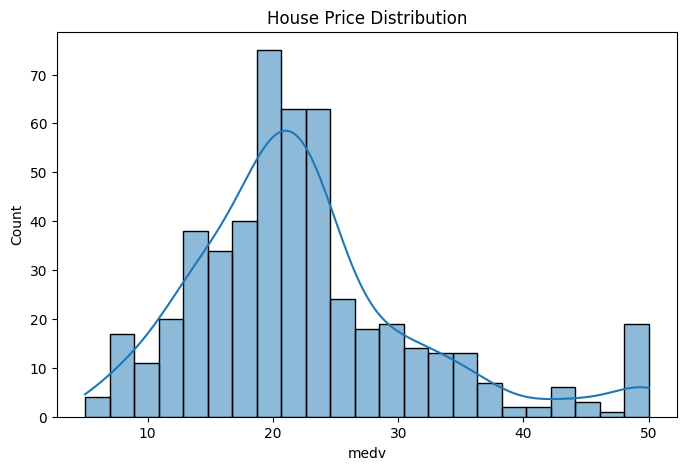

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["medv"], kde=True)
plt.title("House Price Distribution")
plt.show()

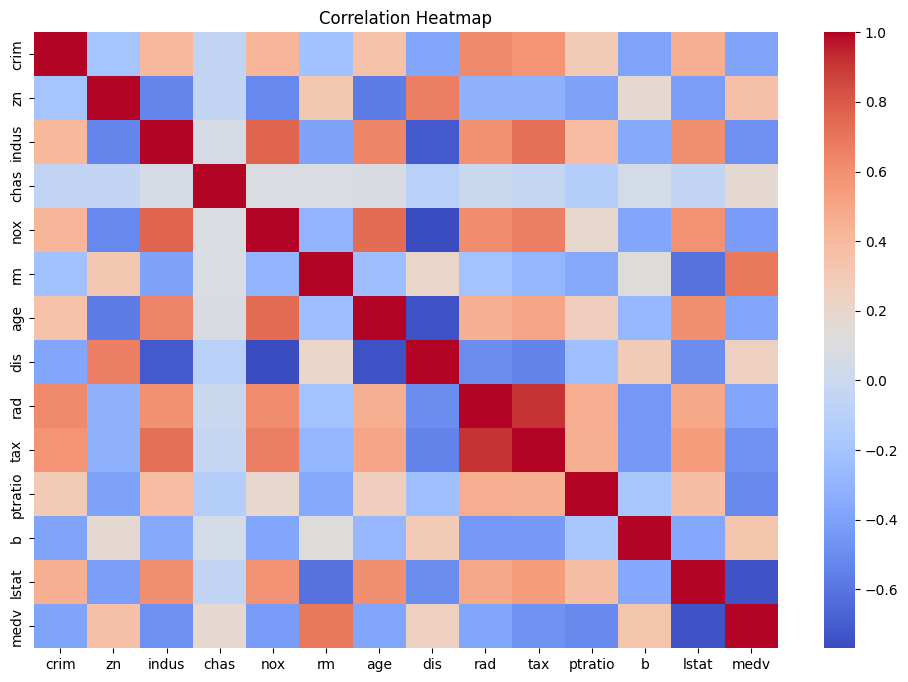

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = df.drop("medv", axis=1)
y = df["medv"]

print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

for depth in range(2, 16):
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("depth =", depth, "R2 =", r2_score(y_test, y_pred))

depth = 2 R2 = 0.6455495710736121
depth = 3 R2 = 0.7713663958398644
depth = 4 R2 = 0.7306868217984426
depth = 5 R2 = 0.8833565347917995
depth = 6 R2 = 0.8782439280592088
depth = 7 R2 = 0.8772230065445347
depth = 8 R2 = 0.8775665426615878
depth = 9 R2 = 0.8787557127850434
depth = 10 R2 = 0.6928415721345185
depth = 11 R2 = 0.850418395142628
depth = 12 R2 = 0.6660492991792228
depth = 13 R2 = 0.7148142623888241
depth = 14 R2 = 0.7004517843254989
depth = 15 R2 = 0.8667448140395886


In [14]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.308156816332771
MSE: 8.553906584646844
RMSE: 2.924706239034417
R2 Score: 0.8833565347917995


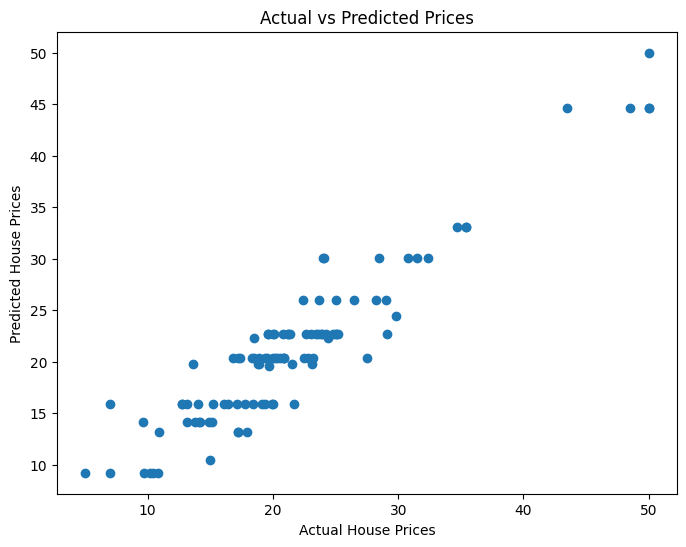

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [17]:
import joblib

joblib.dump(model, "../models/dt_regressor.pkl")

['../models/dt_regressor.pkl']